
# Verification of the $G(j,k)$ and $L(j,k)$ approximations

This notebook compares the exact quantity
$$
\Pi(j,k)=\mathbb{E}\!\left[X\,\mathbf{1}_{X>0}\right],
\qquad
X = 1-\frac{Q}{R^2},
\qquad
Q\sim \chi_n^2(d^2),
$$
to the two analytic approximations discussed in the manuscript:

- the Gaussian moment-matching approximation $G(j,k)$,
- the Laplace approximation $L(j,k)$,
- and the matching approximation $\min\!\left(G(j,k),L(j,k)\right)$.


In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.special import erf, erfcx, gammainc
from scipy.stats import ncx2

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
SQRT2 = math.sqrt(2.0)
SQRT_2_OVER_PI = math.sqrt(2.0 / math.pi)
TARGET = 1e-4


def central_pi(df, R):
    """Exact Pi for a central chi-square with df degrees of freedom."""
    u = R * R
    a = 0.5 * df
    return gammainc(a, u / 2.0) - (2.0 * a / u) * gammainc(a + 1.0, u / 2.0)

def exact_pi(d, R, n, tol=1e-12, max_terms=10000):
    """Exact Pi(d; R, n) using the Poisson-mixture form of the noncentral chi-square law."""
    mu = 0.5 * d * d
    if mu == 0.0:
        return central_pi(n, R)

    # Initial cutoff near the Poisson bulk, with a safety margin.
    jmax = int(max(50, mu + 12.0 * math.sqrt(mu + 1.0) + 10.0))

    total = 0.0
    cumulative_weight = 0.0
    weight = math.exp(-mu)

    for j in range(jmax + 1):
        if j > 0:
            weight *= mu / j
        cumulative_weight += weight
        total += weight * central_pi(n + 2 * j, R)

    j = jmax + 1
    while (1.0 - cumulative_weight) > tol and j < max_terms:
        weight *= mu / j
        cumulative_weight += weight
        total += weight * central_pi(n + 2 * j, R)
        j += 1

    return total



def gaussian_pi(d, R, n):
    mu = 1.0 - (d * d + n) / (R * R)
    sigma = math.sqrt((2.0 * n + 4.0 * d * d) / (R ** 4))

    Phi = lambda z: 0.5 * (1.0 + math.erf(z / SQRT2))
    phi = lambda z: math.exp(-0.5 * z * z) / math.sqrt(2.0 * math.pi)

    z = mu / sigma
    return mu * Phi(z) + sigma * phi(z)

def laplace_pi(d, R, n):
    if d <= 0.0:
        return np.nan
    y = d + n / (2.0 * R) - R
    prefactor = (1.0 / R) * (R / d) ** ((n - 1.0) / 2.0) * math.exp(-0.5 * (d - R) ** 2)
    bracket = SQRT_2_OVER_PI - y * erfcx(y / SQRT2)
    return prefactor * bracket


def matching_pi(d, R, n):
    g = gaussian_pi(d, R, n)
    l = laplace_pi(d, R, n)
    if np.isnan(l):
        return g
    return min(g, l)


def find_dmax(R, n, target=TARGET, upper_guess=10.0):
    f = lambda d: exact_pi(d, R, n) - target
    if f(0.0) < 0.0:
        return 0.0
    hi = upper_guess
    while f(hi) > 0.0:
        hi *= 1.5
        if hi > 100.0:
            raise RuntimeError(f"Could not bracket dmax for n={n}, R={R}")
    return brentq(f, 0.0, hi, xtol=1e-8, rtol=1e-8, maxiter=100)



## Compute the right endpoint $d_{\max}$ for each panel


In [3]:

n_values = [1, 2, 3]
R_values = [1.5, 5, 10]

dmax_map = {}
for n in n_values:
    for R in R_values:
        dmax_map[(n, R)] = find_dmax(R, n)

dmax_map


{(1, 1.5): 4.891408939309782,
 (1, 5): 8.103671849291398,
 (1, 10): 12.915226246696774,
 (2, 1.5): 4.69407766334296,
 (2, 5): 8.023068825637205,
 (2, 10): 12.870594463577303,
 (3, 1.5): 4.484709499854566,
 (3, 5): 7.941534358932064,
 (3, 10): 12.825796544978045}


## Compute the curves


In [4]:

results = {}
num_points = 151

for n in n_values:
    for R in R_values:
        dmax = dmax_map[(n, R)]
        d_grid = np.linspace(0.0, dmax, num_points)

        exact_vals = np.array([exact_pi(float(d), R, n) for d in d_grid])
        g_vals = np.array([gaussian_pi(float(d), R, n) for d in d_grid])
        l_vals = np.array([laplace_pi(float(d), R, n) for d in d_grid])
        m_vals = np.array([matching_pi(float(d), R, n) for d in d_grid])

        results[(n, R)] = {
            "d": d_grid,
            "dmax": dmax,
            "exact": exact_vals,
            "G": g_vals,
            "L": l_vals,
            "min": m_vals,
        }



## Plots



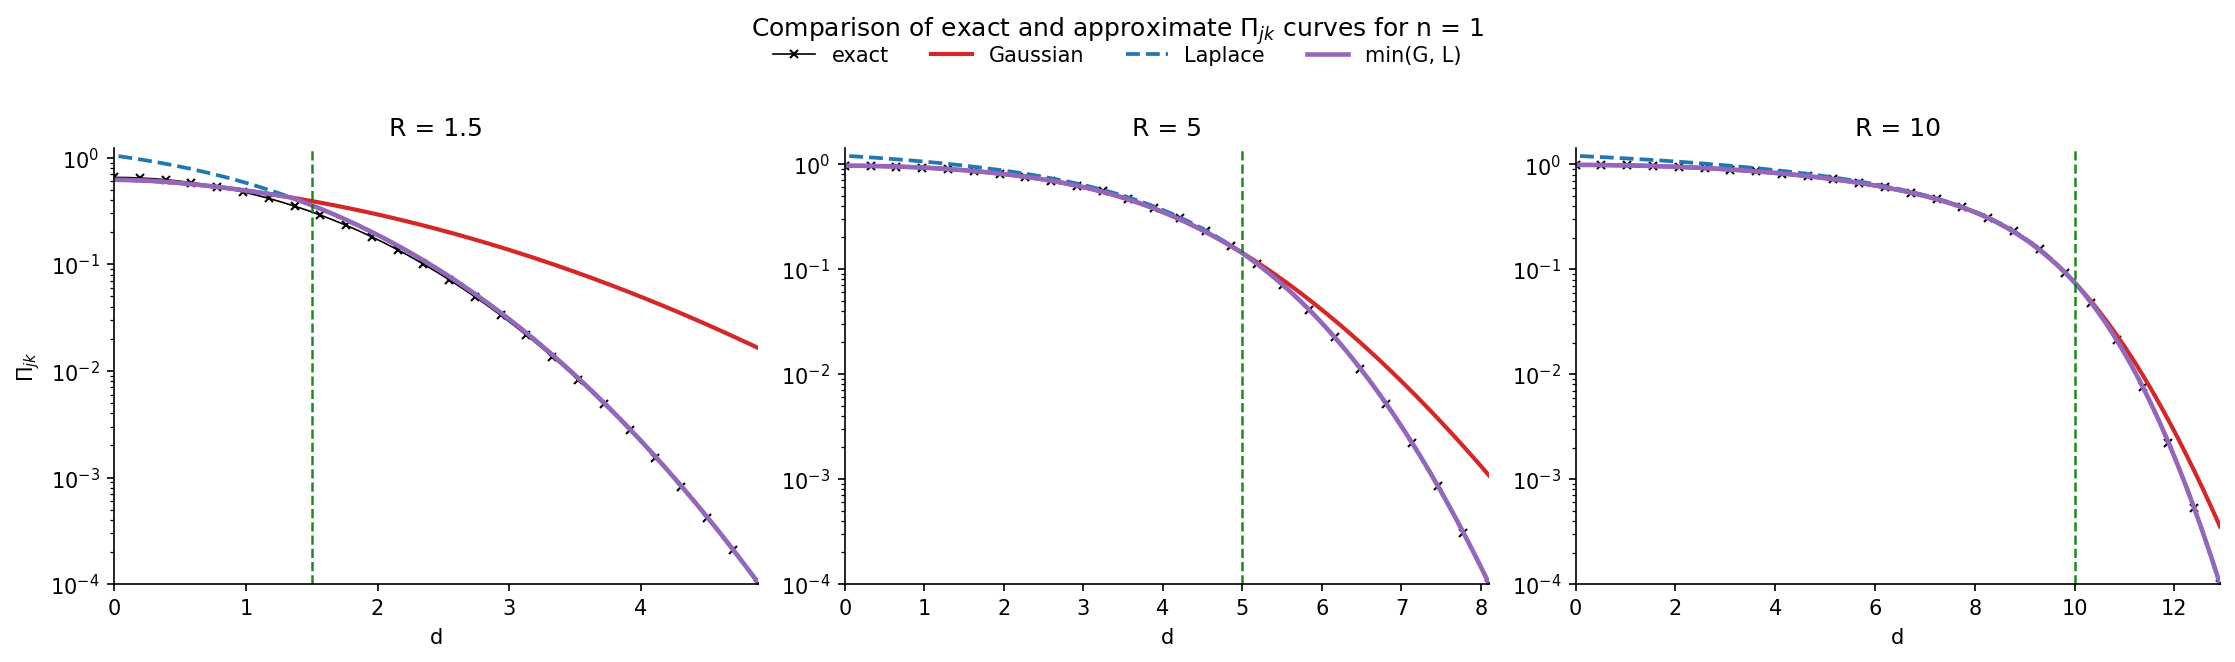

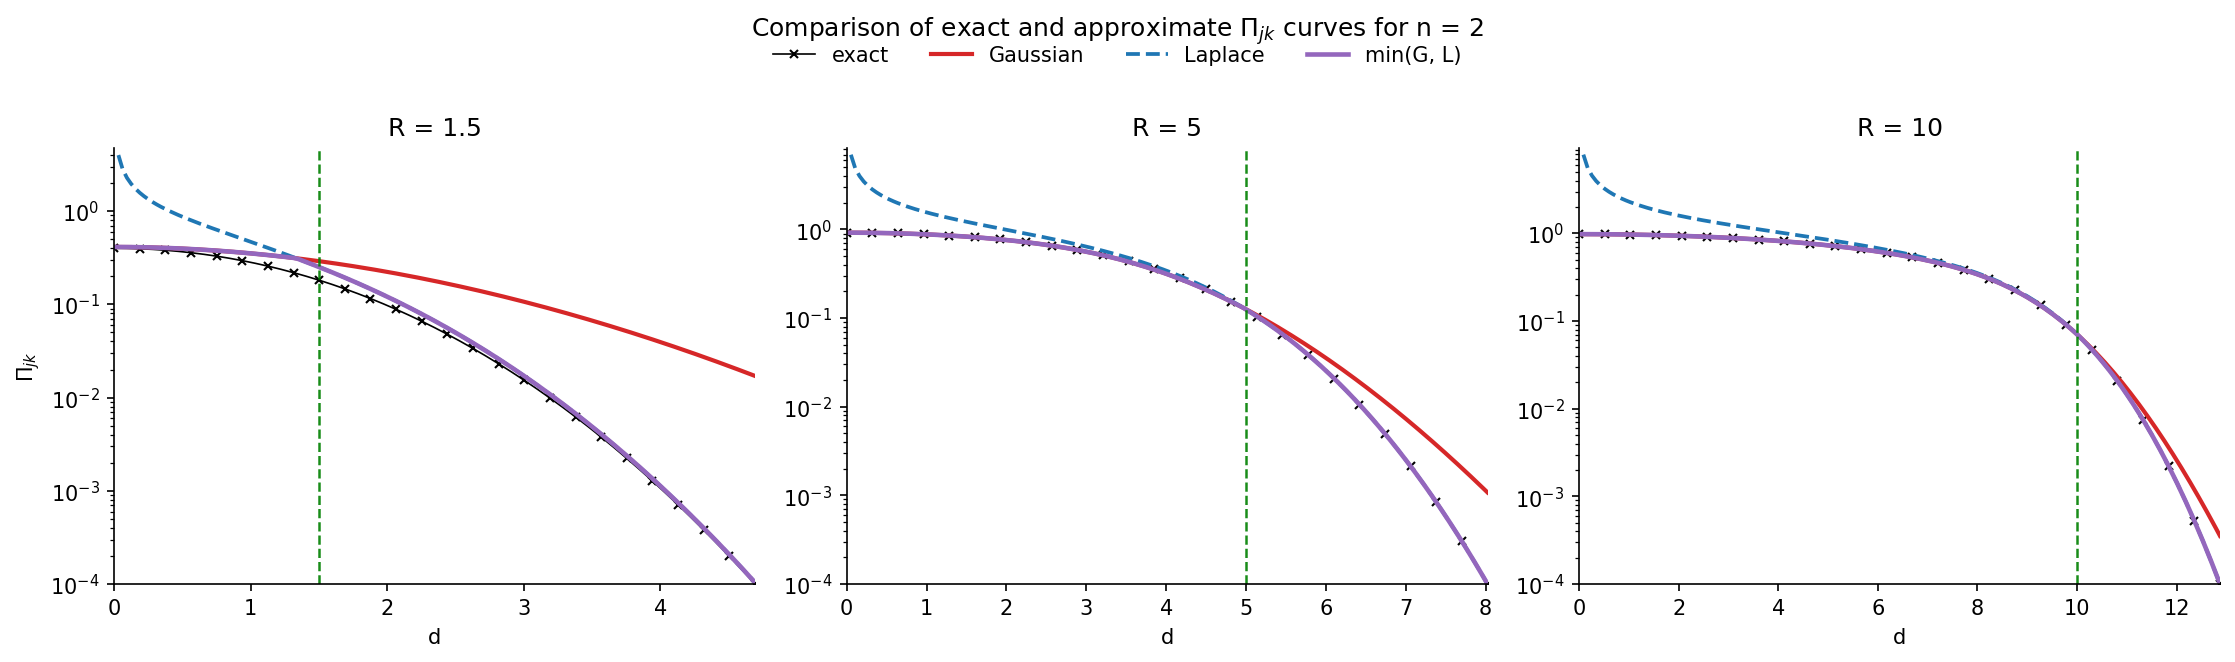

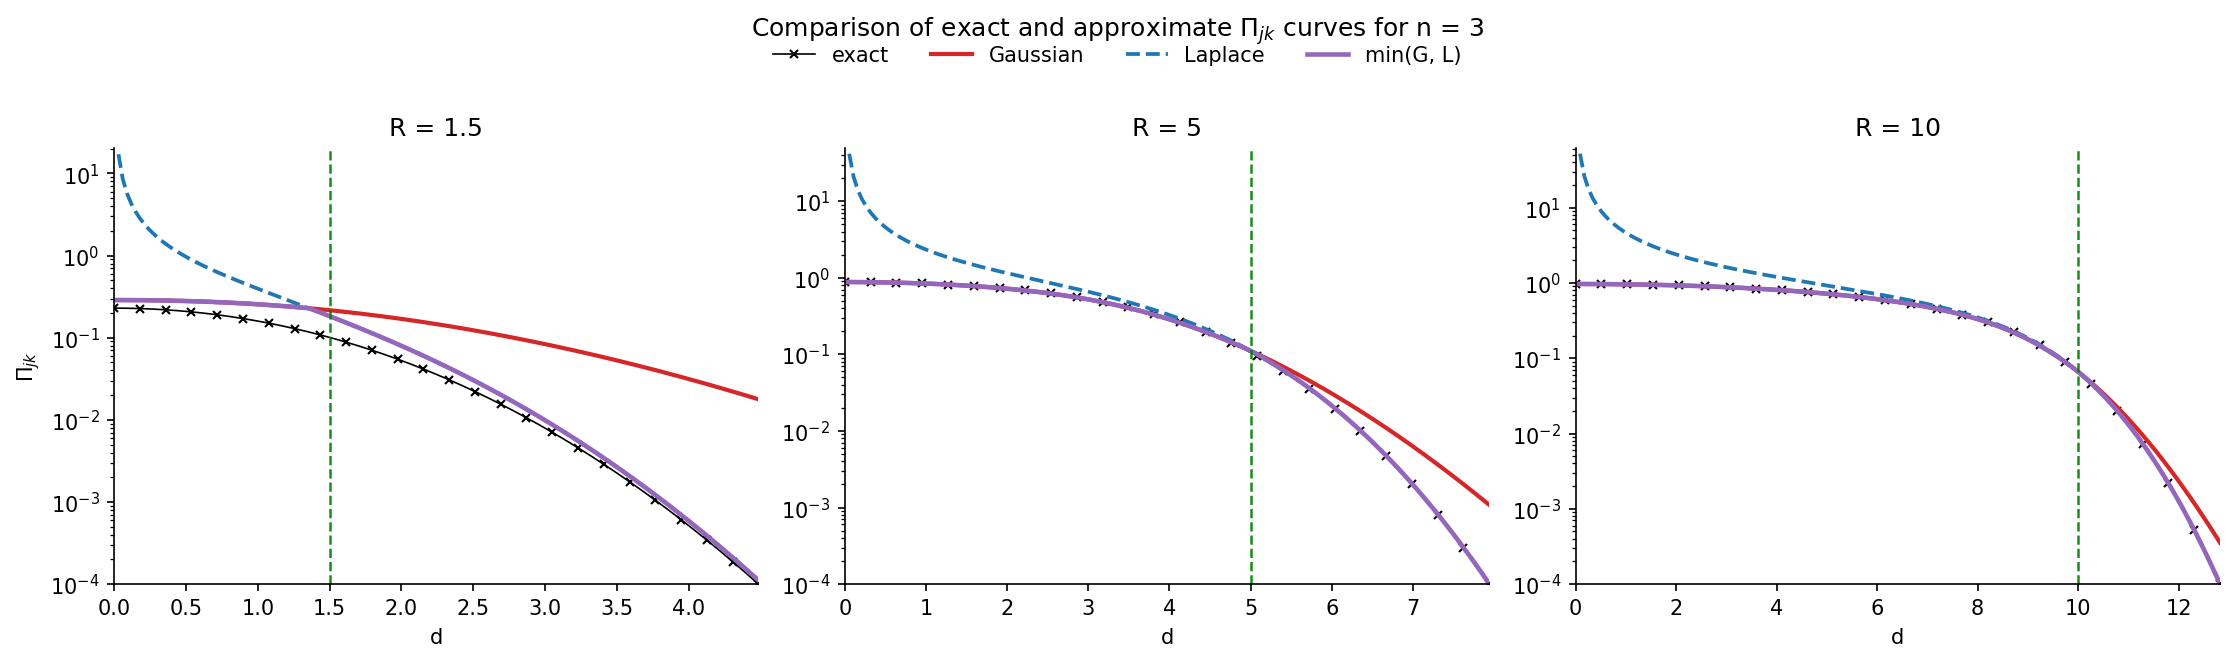

['pi_approx_comparison_n1.png',
 'pi_approx_comparison_n2.png',
 'pi_approx_comparison_n3.png']

In [5]:

def positive_clip(values, floor=1e-300):
    arr = np.asarray(values, dtype=float).copy()
    arr[~np.isfinite(arr)] = np.nan
    arr[(arr <= 0) & np.isfinite(arr)] = floor
    return arr

saved_figure_paths = []

for n in n_values:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)

    for ax, R in zip(axes, R_values):
        data = results[(n, R)]
        d = data["d"]

        ax.plot(
            d,
            positive_clip(data["exact"]),
            color="black",
            linewidth=0.8,
            marker="x",
            markersize=4.0,
            markevery=6,
            label="exact",
        )
        ax.plot(d, positive_clip(data["G"]), label="Gaussian", linewidth=2.0, color="tab:red")
        ax.plot(d, positive_clip(data["L"]), label="Laplace", linewidth=1.8, linestyle="--", color="tab:blue")
        ax.plot(d, positive_clip(data["min"]), label="min(G, L)", linewidth=2.2, color="tab:purple")

        ax.axvline(R, color="green", linestyle="--", linewidth=1.2, alpha=0.9)
        ax.set_yscale("log")
        ax.set_xlim(0.0, data["dmax"])
        ax.set_ylim(TARGET, max(np.nanmax(positive_clip(data["L"])), np.nanmax(positive_clip(data["G"])), np.nanmax(positive_clip(data["exact"])), np.nanmax(positive_clip(data["min"]))) * 1.2)
        ax.set_xlabel("d")
        ax.set_title(f"R = {R:g}")

    axes[0].set_ylabel(r"$\Pi_{{jk}}$ ")
    fig.suptitle(f"Comparison of exact and approximate $\Pi_{{jk}}$ curves for n = {n}", y=1.04)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()

    out_path = f"pi_approx_comparison_n{n}.png"
    fig.savefig(out_path, bbox_inches="tight")
    saved_figure_paths.append(out_path)
    plt.show()

saved_figure_paths
